# 04 — Exact Circular Kerr Orbits and Spin Asymmetry

Notebook 03 validated the reconstructed solver with an exact Schwarzschild
circular orbit and then ran an exploratory Kerr trajectory.

Here we perform a stronger Kerr-specific test.

For equatorial circular timelike geodesics,

\[
\Omega_\pm \equiv \frac{d\phi}{dt}
=
\frac{\pm\sqrt{M}}
     {r^{3/2}\pm a\sqrt{M}},
\]

where the \(+\) branch is prograde for \(a>0\), and the \(-\) branch is
retrograde.

Because Kerr–Schild time and azimuth differ from Boyer–Lindquist time and
azimuth only by functions of \(r\), their derivatives agree for a circular
orbit (\(dr=0\)).

We will use these exact angular velocities to build circular initial
four-velocities directly in Cartesian Kerr–Schild coordinates.


In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from kerr_schild_geodesics.kerr_schild import (
    kerr_radius,
    geodesic_rhs,
    normalization,
    energy_lz,
)
from kerr_schild_geodesics.orbits import (
    circular_omega,
    circular_equatorial_state,
    zamo_omega_equator,
)

print("Project root:", PROJECT_ROOT)


Project root: /home/allanur/Desktop/kerr-schild-geodesics


## 1. Reuse the compiled RK4 integrator

This is the same fourth-order Runge–Kutta method validated against SciPy in
Notebook 03.


In [2]:
@njit
def rk4_step(state, h, M, a):
    k1 = geodesic_rhs(state, M, a)
    k2 = geodesic_rhs(state + 0.5*h*k1, M, a)
    k3 = geodesic_rhs(state + 0.5*h*k2, M, a)
    k4 = geodesic_rhs(state + h*k3, M, a)
    return state + (h/6.0)*(k1 + 2.0*k2 + 2.0*k3 + k4)


@njit
def integrate_rk4(state0, h, n_steps, M, a):
    trajectory = np.empty((n_steps + 1, 8), dtype=np.float64)
    trajectory[0] = state0
    state = state0.copy()

    for n in range(n_steps):
        state = rk4_step(state, h, M, a)
        trajectory[n + 1] = state

    return trajectory


## 2. Exact prograde and retrograde circular states

We choose

\[
M=1,\qquad a=0.5M,\qquad r_0=10M.
\]

Both prograde and retrograde circular orbits are safely outside their
corresponding ISCOs at this radius.


In [3]:
M0 = 1.0
a0 = 0.5
r0 = 10.0

omega_pro = circular_omega(r0, M0, a0, sense=+1)
omega_ret = circular_omega(r0, M0, a0, sense=-1)

state_pro = circular_equatorial_state(r0, M0, a0, sense=+1)
state_ret = circular_equatorial_state(r0, M0, a0, sense=-1)

print("Omega prograde    =", omega_pro)
print("Omega retrograde  =", omega_ret)
print("|Omega retro|/Omega pro =", abs(omega_ret)/omega_pro)
print()

for name, state in [("prograde", state_pro), ("retrograde", state_ret)]:
    E, Lz = energy_lz(state, M0, a0)
    print(name)
    print("  recovered r =", kerr_radius(state[1], state[2], state[3], a0))
    print("  norm        =", normalization(state, M0, a0))
    print("  E           =", E)
    print("  Lz          =", Lz)


Omega prograde    = 0.031130559241494164
Omega retrograde  = -0.0321308093040098
|Omega retro|/Omega pro = 1.03213080930401

prograde
  recovered r = 10.0
  norm        = -1.0000000000000002
  E           = 0.9537754836255026
  Lz          = 3.589390459090457
retrograde
  recovered r = 10.0
  norm        = -1.0
  E           = 0.9592011926920925
  Lz          = -4.000011893806732


The two states should both satisfy

\[
g_{\mu\nu}u^\mu u^\nu=-1
\]

to floating-point precision.

The sign of \(L_z\) should distinguish prograde and retrograde motion.


## 3. Integrate three proper-time orbital periods

For each exact circular state,

\[
u^\phi=\Omega u^t,
\qquad
T_\tau=\frac{2\pi}{|u^\phi|}.
\]


In [4]:
def proper_period(state, omega):
    u_phi = omega * state[4]
    return 2.0*np.pi/abs(u_phi)

T_pro = proper_period(state_pro, omega_pro)
T_ret = proper_period(state_ret, omega_ret)

target_h = 0.02

def integrate_three_periods(state, T):
    lam_end = 3.0*T
    n_steps = int(np.ceil(lam_end/target_h))
    h = lam_end/n_steps
    traj = integrate_rk4(state, h, n_steps, M0, a0)
    return traj, h

# Warm up compilation.
_ = rk4_step(state_pro, 0.02, M0, a0)

start = time.perf_counter()
traj_pro, h_pro = integrate_three_periods(state_pro, T_pro)
traj_ret, h_ret = integrate_three_periods(state_ret, T_ret)
elapsed = time.perf_counter() - start

print("prograde proper-time period   =", T_pro)
print("retrograde proper-time period =", T_ret)
print("prograde h =", h_pro)
print("retrograde h =", h_ret)
print("both integrations runtime =", elapsed, "s")


prograde proper-time period   = 169.95090321484253
retrograde proper-time period = 162.43914288914362
prograde h = 0.01999971402520408
retrograde h = 0.01999989447046831
both integrations runtime = 1.957113754000602 s


## 4. Circularity and invariant conservation

For an exact circular orbit the recovered Kerr radial coordinate should remain
equal to \(r_0\).


In [5]:
def diagnostics(trajectory, label):
    rvals = np.array([
        kerr_radius(s[1], s[2], s[3], a0)
        for s in trajectory
    ])

    sample = trajectory[::10]

    norms = np.array([
        normalization(s, M0, a0)
        for s in sample
    ])

    EL = np.array([
        energy_lz(s, M0, a0)
        for s in sample
    ])

    print(label)
    print("  max |r-r0|   =", np.max(np.abs(rvals-r0)))
    print("  max |norm+1| =", np.max(np.abs(norms+1.0)))
    print("  max |E-E0|   =", np.max(np.abs(EL[:,0]-EL[0,0])))
    print("  max |Lz-Lz0| =", np.max(np.abs(EL[:,1]-EL[0,1])))
    print("  final xyz    =", trajectory[-1,1:4])
    print()

    return rvals, norms, EL

r_pro, norm_pro, EL_pro = diagnostics(traj_pro, "PROGRADE")
r_ret, norm_ret, EL_ret = diagnostics(traj_ret, "RETROGRADE")


PROGRADE
  max |r-r0|   = 3.4638958368304884e-13
  max |norm+1| = 1.7763568394002505e-14
  max |E-E0|   = 8.43769498715119e-15
  max |Lz-Lz0| = 3.9968028886505635e-14
  final xyz    = [ 1.00124922e+01 -1.57703971e-12  0.00000000e+00]

RETROGRADE
  max |r-r0|   = 4.3876013933186186e-13
  max |norm+1| = 1.9539925233402755e-14
  max |E-E0|   = 9.880984919163893e-15
  max |Lz-Lz0| = 5.595524044110789e-14
  final xyz    = [1.00124922e+01 2.16168663e-12 0.00000000e+00]



If our Kerr equations and the circular initial conditions are mutually
consistent, the radial drift should remain tiny for both branches.

## 5. Visualize the two exact circular orbits

The spatial tracks lie on the same coordinate circle at the same \(r_0\), so
the most important distinction is **direction and rate**, not circle shape.


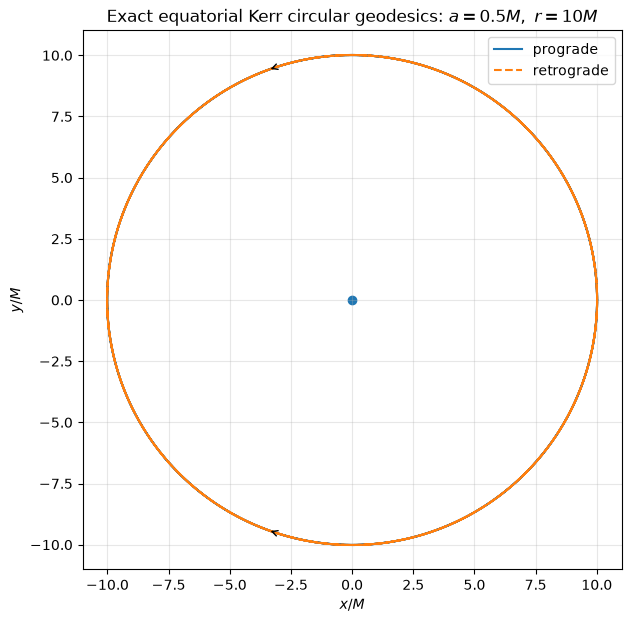

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(traj_pro[:,1], traj_pro[:,2], label="prograde")
ax.plot(traj_ret[:,1], traj_ret[:,2], linestyle="--", label="retrograde")

# Add short direction arrows using nearby points.
for traj in (traj_pro, traj_ret):
    i = len(traj)//10
    j = i + max(1, len(traj)//500)
    ax.annotate(
        "",
        xy=(traj[j,1], traj[j,2]),
        xytext=(traj[i,1], traj[i,2]),
        arrowprops=dict(arrowstyle="->"),
    )

ax.scatter([0.0], [0.0], marker="o")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_title(r"Exact equatorial Kerr circular geodesics: $a=0.5M,\ r=10M$")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig(
    PROJECT_ROOT / "figures" / "kerr_circular_prograde_retrograde.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 6. Spin breaks the prograde/retrograde symmetry

A clean quantitative comparison is the orbital angular velocity seen in the
stationary coordinates.


In [7]:
print("Omega_pro =", omega_pro)
print("Omega_ret =", omega_ret)
print("coordinate period prograde   =", 2*np.pi/abs(omega_pro))
print("coordinate period retrograde =", 2*np.pi/abs(omega_ret))


Omega_pro = 0.031130559241494164
Omega_ret = -0.0321308093040098
coordinate period prograde   = 201.83335796951184
coordinate period retrograde = 195.5501726623322


## 7. A direct frame-dragging diagnostic: zero-angular-momentum observers

For a stationary axisymmetric spacetime, an observer with zero axial angular
momentum satisfies

\[
0=p_\phi
=
g_{t\phi}u^t+g_{\phi\phi}u^\phi.
\]

Therefore

\[
\boxed{
\Omega_{\rm ZAMO}
=
\frac{d\phi}{dt}
=
-\frac{g_{t\phi}}{g_{\phi\phi}}
}
\]

For \(a>0\), this is positive: even a zero-angular-momentum observer is dragged
in the direction of the black-hole spin.


In [8]:
r_grid = np.linspace(2.2, 20.0, 300)
omega_drag = np.array([
    zamo_omega_equator(rv, M0, a0)
    for rv in r_grid
])

print("Omega_ZAMO at r=10M =", zamo_omega_equator(10.0, M0, a0))
print("Omega_ZAMO at r=5M  =", zamo_omega_equator(5.0, M0, a0))
print("Omega_ZAMO at r=3M  =", zamo_omega_equator(3.0, M0, a0))


Omega_ZAMO at r=10M = 0.0009970089730807579
Omega_ZAMO at r=5M  = 0.007889546351084813
Omega_ZAMO at r=3M  = 0.03539823008849558


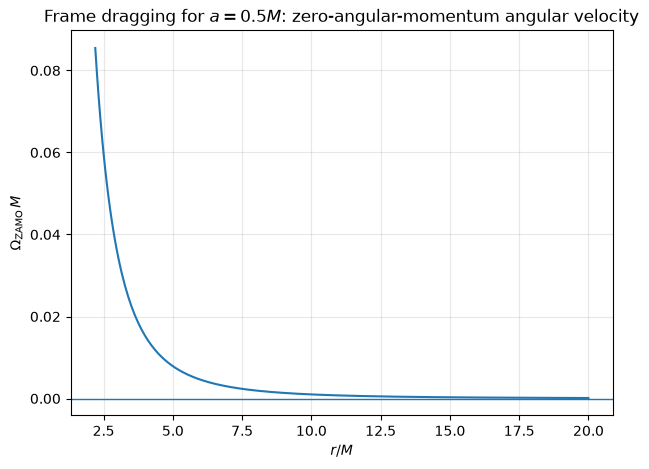

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(r_grid, omega_drag)
ax.axhline(0.0, linewidth=1.0)

ax.set_xlabel(r"$r/M$")
ax.set_ylabel(r"$\Omega_{\mathrm{ZAMO}}\,M$")
ax.set_title(
    r"Frame dragging for $a=0.5M$: "
    r"zero-angular-momentum angular velocity"
)

ax.grid(True, alpha=0.3)


plt.savefig(
    PROJECT_ROOT / "figures" / "kerr_frame_dragging_zamo.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Interpretation

This notebook gives us two Kerr-specific validation layers:

1. **Exact circular geodesics:** prograde and retrograde initial data should
   remain circular while conserving normalization, \(E\), and \(L_z\).

2. **Frame dragging:** the nonzero
   \(\Omega_{\rm ZAMO}=-g_{t\phi}/g_{\phi\phi}\) directly demonstrates that
   the rotating spacetime drags zero-angular-momentum observers in the spin
   direction.

These are scientifically cleaner demonstrations than comparing a
Schwarzschild circular orbit with an arbitrarily initialized Kerr trajectory.

The next stage can move from validation to genuinely interesting trajectory
families: eccentric bound orbits, plunges, photon capture/scattering, and
near-horizon frame dragging.
